SvN

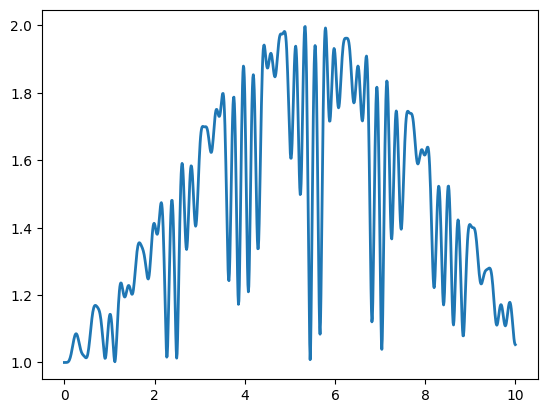

In [21]:
plt.plot(t, SvN, label=rf"Config {config}", linewidth=2)

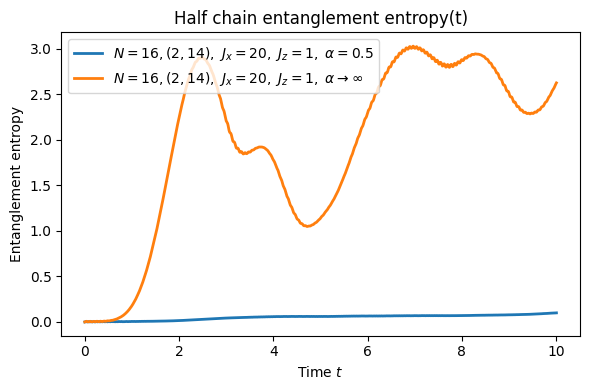

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def stream_vn_entropy(path, base=2, clip=1e-15):
    """
    Stream rho_L(t) from file, compute von Neumann entropy per timestep,
    and return time array + entropy array.
    """
    times = []
    SvN = []

    ns_val = None
    L_val = None
    dL = None
    expected = None

    with open(path, "r") as f:
        for line_idx, line in enumerate(f):
            line = line.strip()
            if not line:
                continue

            # Parse: t  ns  L  (rest = rho data)
            parts = line.split(maxsplit=3)
            if len(parts) < 4:
                raise ValueError(f"Malformed line {line_idx}")

            t = float(parts[0])
            ns = int(parts[1])
            L  = int(parts[2])
            data_str = parts[3]

            if ns_val is None:
                ns_val, L_val = ns, L
                dL = 1 << L_val
                expected = 2 * dL * dL
            else:
                if ns != ns_val or L != L_val:
                    raise ValueError(f"Inconsistent ns/L at line {line_idx}")

            data = np.fromstring(data_str, sep=' ', dtype=np.float64)
            if data.size != expected:
                raise ValueError(
                    f"Bad row length at t={t}: expected {expected}, got {data.size}"
                )

            # Build rho
            rho = data.reshape(dL * dL, 2)
            rho = (rho[:, 0] + 1j * rho[:, 1]).reshape(dL, dL)

            # Symmetrize to kill numerical noise
            rho = 0.5 * (rho + rho.conj().T)

            # Eigenvalues
            w = np.linalg.eigvalsh(rho)
            w = np.clip(np.real(w), 0.0, None)

            # Normalize (safety)
            s = w.sum()
            if s > 0:
                w /= s

            nz = w[w > clip]
            if base == 2:
                SvN.append(-(nz * np.log2(nz)).sum())
            else:
                SvN.append(-(nz * np.log(nz)).sum() / np.log(base))

            times.append(t)

    return np.array(times), np.array(SvN), ns_val, L_val


# -----------------------------
# Plot: superimpose configs
# -----------------------------

configs = [5, 1000]

base_path = (
    r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots"
    r"\CYPRESS\Concurrence\Ran\Entanglement"
)

plt.figure(figsize=(6, 4))

for cfg in configs:
    path = f"{base_path}{cfg}Concurrence.txt"
    t, SvN, ns, L = stream_vn_entropy(path)

    if cfg == 1000:
        label = rf"$N=16, (2,14),\ J_x=20,\ J_z=1,\ \alpha\to\infty$"
    else:
        label = rf"$N=16, (2,14),\ J_x=20,\ J_z=1,\ \alpha=0.5$"

    plt.plot(t, SvN, lw=2, label=label)

plt.xlabel(r"Time $t$")
plt.ylabel(r"Entanglement entropy")
plt.title(r"Half chain entanglement entropy(t)")
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("SvN_vs_time2.pdf", bbox_inches="tight")
plt.show()



Sanity checks

In [18]:

print(np.shape(rhos[500]))

# print(np.shape(rhos))

# print(f"at time 0: {rhos[0]}")
# print(f"at time 5: {rhos[500]}")
# print(f"at time 10: {rhos[1000]}")
with np.printoptions(
    precision=6,
    suppress=False,
    linewidth=200,
    threshold=np.inf
):
    print("rho_L(t=5):")
    print(rhos[500])


print(SvN[500])

(4, 4)
rho_L(t=5):
[[ 0.214275+0.j        0.      +0.j        0.      +0.j       -0.15871 -0.037546j]
 [ 0.      +0.j        0.285725+0.j        0.15871 +0.037546j  0.      +0.j      ]
 [ 0.      +0.j        0.15871 -0.037546j  0.214275+0.j        0.      +0.j      ]
 [-0.15871 +0.037546j  0.      +0.j        0.      +0.j        0.285725+0.j      ]]
1.6486680353305745


Bell pair test, entropy should start at 1

[config=0] t=0 checks: {'dim': 32, 'trace_real': 1.0, 'trace_imag': 0.0, 'herm_fro_err': 0.0, 'min_eig': 0.0, 'trace_ok': np.True_, 'herm_ok': np.True_, 'psd_ok': True}
[config=0] t=4 checks: {'dim': 32, 'trace_real': 0.9999999999999999, 'trace_imag': 0.0, 'herm_fro_err': 0.0, 'min_eig': 8.038202903891386e-09, 'trace_ok': np.True_, 'herm_ok': np.True_, 'psd_ok': True}
[config=0] t=8 checks: {'dim': 32, 'trace_real': 1.0000000000000002, 'trace_imag': 0.0, 'herm_fro_err': 0.0, 'min_eig': 1.5274206054015178e-09, 'trace_ok': np.True_, 'herm_ok': np.True_, 'psd_ok': True}
[config=1] t=0 checks: {'dim': 32, 'trace_real': 1.0, 'trace_imag': 0.0, 'herm_fro_err': 0.0, 'min_eig': 0.0, 'trace_ok': np.True_, 'herm_ok': np.True_, 'psd_ok': True}
[config=1] t=4 checks: {'dim': 32, 'trace_real': 0.9999999999999998, 'trace_imag': 0.0, 'herm_fro_err': 0.0, 'min_eig': 6.380388859334731e-10, 'trace_ok': np.True_, 'herm_ok': np.True_, 'psd_ok': True}
[config=1] t=8 checks: {'dim': 32, 'trace_real': 1.0, '

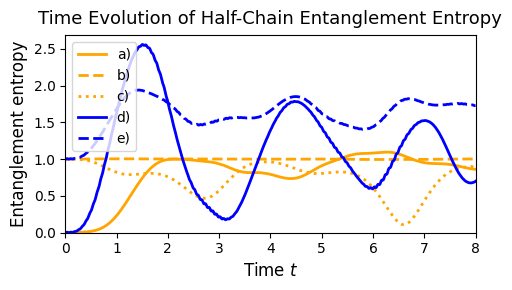

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

def read_rhoL_file(path, strict=True):
    """
    Reads file format:
      t ns L  Re00 Im00 Re01 Im01 ... Re(dL-1,dL-1) Im(...)
    Returns:
      times: (T,)
      ns: int
      L: int
      rhos: list of (dL,dL) complex arrays, length T
    """
    times = []
    rhos = []
    ns_val = None
    L_val = None

    with open(path, "r") as f:
        for lineno, line in enumerate(f, start=1):
            if not line.strip():
                continue
            vals = line.split()

            if len(vals) < 3:
                msg = f"{path}:{lineno} too few columns; skipping."
                if strict:
                    raise ValueError(msg)
                warnings.warn(msg)
                continue

            try:
                t = float(vals[0])
                ns = int(vals[1])
                L  = int(vals[2])
            except Exception as e:
                msg = f"{path}:{lineno} failed to parse header (t,ns,L): {e}; skipping."
                if strict:
                    raise ValueError(msg)
                warnings.warn(msg)
                continue

            if ns_val is None:
                ns_val, L_val = ns, L
            else:
                if ns != ns_val or L != L_val:
                    raise ValueError(
                        f"Inconsistent ns/L in file. Saw ns={ns},L={L} but expected ns={ns_val},L={L_val}"
                    )

            dL = 1 << L

            try:
                data = np.array(list(map(float, vals[3:])), dtype=float)
            except Exception as e:
                msg = f"{path}:{lineno} failed to parse payload floats: {e}; skipping."
                if strict:
                    raise ValueError(msg)
                warnings.warn(msg)
                continue

            expected = 2 * dL * dL
            if data.size != expected:
                msg = (f"{path}:{lineno} bad row length at t={t}: "
                       f"expected {expected} floats, got {data.size}; skipping.")
                if strict:
                    raise ValueError(msg)
                warnings.warn(msg)
                continue

            data = data.reshape(dL * dL, 2)
            rho = data[:, 0] + 1j * data[:, 1]
            rho = rho.reshape(dL, dL)

            times.append(t)
            rhos.append(rho)

    if ns_val is None:
        raise ValueError(f"{path}: no valid data rows parsed.")

    return np.array(times), ns_val, L_val, rhos


def von_neumann_entropy(rho, base=2, clip=1e-15):
    rhoH = 0.5 * (rho + rho.conj().T)
    w = np.linalg.eigvalsh(rhoH)
    w = np.real(w)

    w = np.clip(w, 0.0, 1.0)
    tr = w.sum()
    if tr > 0:
        w = w / tr

    nz = w[w > clip]
    if base == 2:
        return float(-(nz * np.log2(nz)).sum())
    else:
        return float(-(nz * np.log(nz)).sum() / np.log(base))


def renyi2_entropy(rho, base=2, clip=1e-15):
    rhoH = 0.5 * (rho + rho.conj().T)
    tr_rho2 = np.real(np.trace(rhoH @ rhoH))
    tr_rho2 = max(tr_rho2, clip)
    if base == 2:
        return float(-np.log2(tr_rho2))
    else:
        return float(-np.log(tr_rho2) / np.log(base))


def sanity_checks(rho, tol_trace=1e-8, tol_herm=1e-8, tol_neg=1e-10):
    d = rho.shape[0]
    tr = np.trace(rho)
    herm_err = np.linalg.norm(rho - rho.conj().T, ord="fro")
    rhoH = 0.5 * (rho + rho.conj().T)
    w = np.linalg.eigvalsh(rhoH)
    w = np.real(w)
    min_eig = float(np.min(w))

    return {
        "dim": d,
        "trace_real": float(np.real(tr)),
        "trace_imag": float(np.imag(tr)),
        "herm_fro_err": float(herm_err),
        "min_eig": min_eig,
        "trace_ok": abs(np.real(tr) - 1.0) < tol_trace and abs(np.imag(tr)) < tol_trace,
        "herm_ok": herm_err < tol_herm,
        "psd_ok": min_eig > -tol_neg,
    }


# -----------------------------
# USER SETTINGS
# -----------------------------
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\EntanglementTest"
configs_to_plot = [0, 1, 4, 3, 2]

alpha_val = 0.5
Jx_val = 20
tmax_val = 8
# -----------------------------


plt.figure(figsize=(5, 3))

for config in configs_to_plot:
    path = f"{base}{config}Concurrence.txt"

    # CHANGED: strict=False to tolerate incomplete files
    t, ns, L, rhos = read_rhoL_file(path, strict=False)

    # CHANGED: sort by time (safety)
    order = np.argsort(t)
    t = t[order]
    rhos = [rhos[i] for i in order]

    # CHANGED: mask to t <= tmax_val
    mask = (t <= tmax_val)
    t = t[mask]
    rhos = [r for r, m in zip(rhos, mask) if m]

    # CHANGED: skip config if nothing remains after masking
    if len(rhos) == 0:
        print(f"[config={config}] No valid rows up to tmax={tmax_val}. Skipping.")
        continue

    SvN = np.array([von_neumann_entropy(r) for r in rhos])
    # S2  = np.array([renyi2_entropy(r) for r in rhos])

    for idx in [0, len(rhos)//2, len(rhos)-1]:
        chk = sanity_checks(rhos[idx])
        print(f"[config={config}] t={t[idx]:.6g} checks:", chk)

    # if config == 0:
    #     label = rf"Prod state: $(2,8)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    #     style = dict(linestyle="-", linewidth=2, color="orange")
    # elif config == 1:
    #     label = rf"Entangled state: $(2;8)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    #     style = dict(linestyle="--", linewidth=2, color="orange")
    # elif config == 2:
    #     label = rf"Entangled state: $(2;8)$, $N={ns}$, $\alpha\to\infty$, $J_x={Jx_val}$"
    #     style = dict(linestyle="--", linewidth=2, color="blue")
    # elif config == 3:
    #     label = rf"Prod state: $(2,8)$, $N={ns}$, $\alpha\to\infty$, $J_x={Jx_val}$"
    #     style = dict(linestyle="-", linewidth=2, color="blue")
    # elif config == 4:
    #     label = rf"Entangled state: $(2;6)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    #     style = dict(linestyle=":", linewidth=2, color="orange")
    if config == 0:
        label = rf"a)"
        style = dict(linestyle="-", linewidth=2, color="orange")
    elif config == 1:
        label = rf"b)"
        style = dict(linestyle="--", linewidth=2, color="orange")
    elif config == 2:
        label = rf"e)"
        style = dict(linestyle="--", linewidth=2, color="blue")
    elif config == 3:
        label = rf"d)"
        style = dict(linestyle="-", linewidth=2, color="blue")
    elif config == 4:
        label = rf"c)"
        style = dict(linestyle=":", linewidth=2, color="orange")

    plt.plot(t, SvN, label=label, **style)
    # plt.plot(t, S2, label=label + r" (Renyi-2)", linewidth=1.5, alpha=0.8)

plt.xlabel(r"Time $t$", fontsize=12)
plt.ylabel(r"Entanglement entropy", fontsize=12)
plt.title(r"Time Evolution of Half-Chain Entanglement Entropy", fontsize=13, pad=8)

plt.legend(frameon=True, fontsize=10)
plt.xlim(0, tmax_val)
plt.ylim(0, None)

plt.tight_layout()
plt.savefig("plt/SvN_vs_time.svg", bbox_inches="tight")
plt.show()


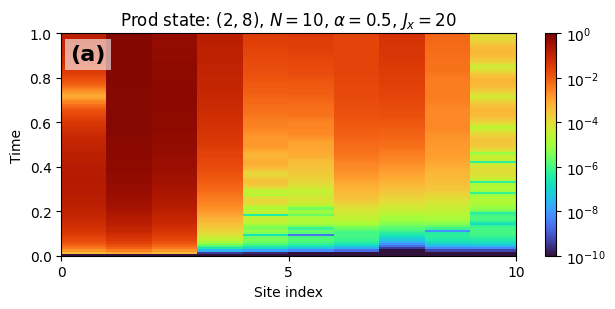

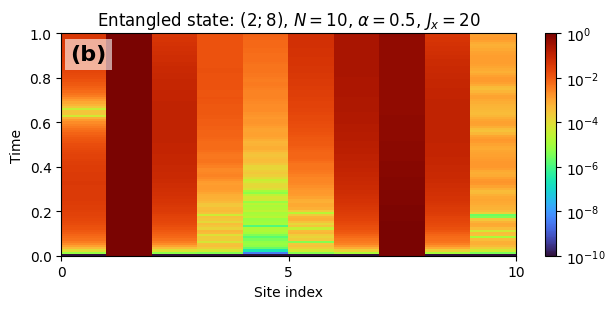

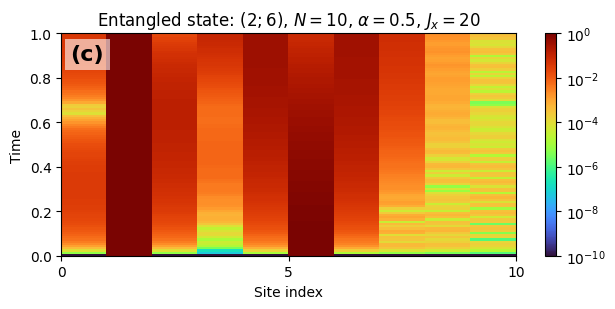

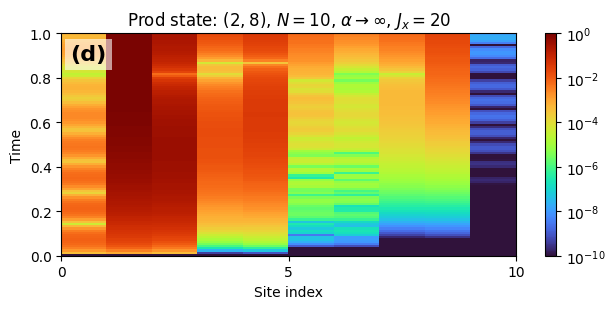

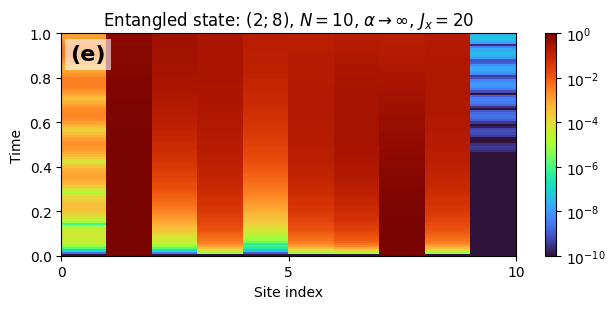

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -----------------------------
# SETTINGS
# -----------------------------
configsArray = [0, 1, 4, 3, 2]
t_max_plot = 1.0
ns = 10
Jx_val = 20

base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\EntanglementTest"
panel_letters = [f"({chr(97+i)})" for i in range(len(configsArray))]

for idx, config in enumerate(configsArray):

    fnameCorr = f"{base}{config}CorrelationFunction.txt"

    # ---------------------------------------
    # MASK AT LOAD TIME (stop before bad rows)
    # ---------------------------------------
    times_only = np.loadtxt(fnameCorr, usecols=0)
    n_keep = np.sum(times_only <= t_max_plot)

    if n_keep == 0:
        print(f"[config={config}] No rows with t <= {t_max_plot}. Skipping.")
        continue

    dataCorr = np.loadtxt(fnameCorr, max_rows=n_keep)

    # ---------------------------------------
    # Correlation data
    # ---------------------------------------
    times_corr = dataCorr[:, 0]
    CorrMat = np.abs(dataCorr[:, 1:ns+1])

    t_min, t_max = float(times_corr.min()), float(times_corr.max())
    extent = [0, ns, t_min, t_max]

    # ---------------------------------------
    # Title logic (EXACTLY as requested)
    # ---------------------------------------
    if config == 0:
        title = rf"Prod state: $(2,8)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    elif config == 1:
        title = rf"Entangled state: $(2;8)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    elif config == 2:
        title = rf"Entangled state: $(2;8)$, $N={ns}$, $\alpha\to\infty$, $J_x={Jx_val}$"
    elif config == 3:
        title = rf"Prod state: $(2,8)$, $N={ns}$, $\alpha\to\infty$, $J_x={Jx_val}$"
    elif config == 4:
        title = rf"Entangled state: $(2;6)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    else:
        title = f"Config {config}"

    # ---------------------------------------
    # PLOT (correlation only)
    # ---------------------------------------
    fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.2))

    im = ax.imshow(
        np.clip(CorrMat, 1e-10, None),
        origin="lower",
        aspect="auto",
        cmap="turbo",
        interpolation="nearest",
        norm=mcolors.LogNorm(vmin=1e-10, vmax=1),
        extent=extent
    )

    ax.set_title(title)
    ax.set_xlabel("Site index")
    ax.set_ylabel("Time")

    x_ticks = np.arange(0, ns + 1, 5)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{int(x)}" for x in x_ticks])

    # panel letter
    ax.text(
        0.02, 0.95, panel_letters[idx],
        transform=ax.transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f"plt/Corr_Config{config}.svg", dpi=600, bbox_inches="tight")
    plt.show()


In [57]:
SvN

array([1.        , 1.00134227, 1.00349037, 1.00425537, 1.00295033,
       1.00085172, 1.00034197, 1.00213015, 1.00396296, 1.00404898,
       1.00235296, 1.0005953 , 1.00087332, 1.00276963, 1.00410018,
       1.00360885, 1.00184439, 1.00072713, 1.0015504 , 1.00326811,
       1.00400814, 1.00310561, 1.0015541 , 1.0010913 , 1.00215702,
       1.00351821, 1.00374157, 1.00269861, 1.0016039 , 1.00164504,
       1.00271833, 1.00364171, 1.00347288, 1.00250708, 1.00189235,
       1.00220667, 1.0030983 , 1.00358714, 1.0031964 , 1.00247751,
       1.00224994, 1.00266184, 1.00331058, 1.00349371, 1.00309446,
       1.00268594, 1.00266926, 1.00304402, 1.00347513, 1.0035119 ,
       1.00322669, 1.00302433, 1.00306681, 1.00337762, 1.00368382,
       1.0036888 , 1.00351724, 1.00340048, 1.00344433, 1.00369785,
       1.00391758, 1.00392225, 1.00383865, 1.00376567, 1.00379487,
       1.00397577, 1.00412812, 1.00418966, 1.004212  , 1.00416346,
       1.00413438, 1.0042086 , 1.00433258, 1.00450684, 1.00461

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

def read_rhoL_file(path, strict=True):
    """
    Reads file format:
      t ns L  Re00 Im00 Re01 Im01 ... Re(dL-1,dL-1) Im(...)
    Returns:
      times: (T,)
      ns: int
      L: int
      rhos: list of (dL,dL) complex arrays, length T
    """
    times = []
    rhos = []
    ns_val = None
    L_val = None

    with open(path, "r") as f:
        for lineno, line in enumerate(f, start=1):
            if not line.strip():
                continue
            vals = line.split()

            if len(vals) < 3:
                msg = f"{path}:{lineno} too few columns; skipping."
                if strict:
                    raise ValueError(msg)
                warnings.warn(msg)
                continue

            try:
                t = float(vals[0])
                ns = int(vals[1])
                L  = int(vals[2])
            except Exception as e:
                msg = f"{path}:{lineno} failed to parse header (t,ns,L): {e}; skipping."
                if strict:
                    raise ValueError(msg)
                warnings.warn(msg)
                continue

            if ns_val is None:
                ns_val, L_val = ns, L
            else:
                if ns != ns_val or L != L_val:
                    raise ValueError(
                        f"Inconsistent ns/L in file. Saw ns={ns},L={L} but expected ns={ns_val},L={L_val}"
                    )

            dL = 1 << L

            try:
                data = np.array(list(map(float, vals[3:])), dtype=float)
            except Exception as e:
                msg = f"{path}:{lineno} failed to parse payload floats: {e}; skipping."
                if strict:
                    raise ValueError(msg)
                warnings.warn(msg)
                continue

            expected = 2 * dL * dL
            if data.size != expected:
                msg = (f"{path}:{lineno} bad row length at t={t}: "
                       f"expected {expected} floats, got {data.size}; skipping.")
                if strict:
                    raise ValueError(msg)
                warnings.warn(msg)
                continue

            data = data.reshape(dL * dL, 2)
            rho = data[:, 0] + 1j * data[:, 1]
            rho = rho.reshape(dL, dL)

            times.append(t)
            rhos.append(rho)

    if ns_val is None:
        raise ValueError(f"{path}: no valid data rows parsed.")

    return np.array(times), ns_val, L_val, rhos


def von_neumann_entropy(rho, base=2, clip=1e-15):
    rhoH = 0.5 * (rho + rho.conj().T)
    w = np.linalg.eigvalsh(rhoH)
    w = np.real(w)

    w = np.clip(w, 0.0, 1.0)
    tr = w.sum()
    if tr > 0:
        w = w / tr

    nz = w[w > clip]
    if base == 2:
        return float(-(nz * np.log2(nz)).sum())
    else:
        return float(-(nz * np.log(nz)).sum() / np.log(base))


def renyi2_entropy(rho, base=2, clip=1e-15):
    rhoH = 0.5 * (rho + rho.conj().T)
    tr_rho2 = np.real(np.trace(rhoH @ rhoH))
    tr_rho2 = max(tr_rho2, clip)
    if base == 2:
        return float(-np.log2(tr_rho2))
    else:
        return float(-np.log(tr_rho2) / np.log(base))


def sanity_checks(rho, tol_trace=1e-8, tol_herm=1e-8, tol_neg=1e-10):
    d = rho.shape[0]
    tr = np.trace(rho)
    herm_err = np.linalg.norm(rho - rho.conj().T, ord="fro")
    rhoH = 0.5 * (rho + rho.conj().T)
    w = np.linalg.eigvalsh(rhoH)
    w = np.real(w)
    min_eig = float(np.min(w))

    return {
        "dim": d,
        "trace_real": float(np.real(tr)),
        "trace_imag": float(np.imag(tr)),
        "herm_fro_err": float(herm_err),
        "min_eig": min_eig,
        "trace_ok": abs(np.real(tr) - 1.0) < tol_trace and abs(np.imag(tr)) < tol_trace,
        "herm_ok": herm_err < tol_herm,
        "psd_ok": min_eig > -tol_neg,
    }


# -----------------------------
# USER SETTINGS
# -----------------------------
base = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR\Entanglement"
configs_to_plot = [5]

alpha_val = 0.5
Jx_val = 20
tmax_val = 8
# -----------------------------


plt.figure(figsize=(5, 3))

for config in configs_to_plot:
    path = f"{base}{config}Concurrence.txt"

    # CHANGED: strict=False to tolerate incomplete files
    t, ns, L, rhos = read_rhoL_file(path, strict=False)

    # CHANGED: sort by time (safety)
    order = np.argsort(t)
    t = t[order]
    rhos = [rhos[i] for i in order]

    # CHANGED: mask to t <= tmax_val
    mask = (t <= tmax_val)
    t = t[mask]
    rhos = [r for r, m in zip(rhos, mask) if m]

    # CHANGED: skip config if nothing remains after masking
    if len(rhos) == 0:
        print(f"[config={config}] No valid rows up to tmax={tmax_val}. Skipping.")
        continue

    SvN = np.array([von_neumann_entropy(r) for r in rhos])
    # S2  = np.array([renyi2_entropy(r) for r in rhos])

    for idx in [0, len(rhos)//2, len(rhos)-1]:
        chk = sanity_checks(rhos[idx])
        print(f"[config={config}] t={t[idx]:.6g} checks:", chk)

    # if config == 0:
    #     label = rf"Prod state: $(2,8)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    #     style = dict(linestyle="-", linewidth=2, color="orange")
    # elif config == 1:
    #     label = rf"Entangled state: $(2;8)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    #     style = dict(linestyle="--", linewidth=2, color="orange")
    # elif config == 2:
    #     label = rf"Entangled state: $(2;8)$, $N={ns}$, $\alpha\to\infty$, $J_x={Jx_val}$"
    #     style = dict(linestyle="--", linewidth=2, color="blue")
    # elif config == 3:
    #     label = rf"Prod state: $(2,8)$, $N={ns}$, $\alpha\to\infty$, $J_x={Jx_val}$"
    #     style = dict(linestyle="-", linewidth=2, color="blue")
    # elif config == 4:
    #     label = rf"Entangled state: $(2;6)$, $N={ns}$, $\alpha=0.5$, $J_x={Jx_val}$"
    #     style = dict(linestyle=":", linewidth=2, color="orange")
    if config == 0:
        label = rf"a)"
        style = dict(linestyle="-", linewidth=2, color="orange")
    elif config == 1:
        label = rf"b)"
        style = dict(linestyle="--", linewidth=2, color="orange")
    elif config == 2:
        label = rf"e)"
        style = dict(linestyle="--", linewidth=2, color="blue")
    elif config == 3:
        label = rf"d)"
        style = dict(linestyle="-", linewidth=2, color="blue")
    elif config == 4:
        label = rf"c)"
        style = dict(linestyle=":", linewidth=2, color="orange")

    plt.plot(t, SvN, label=label, **style)
    # plt.plot(t, S2, label=label + r" (Renyi-2)", linewidth=1.5, alpha=0.8)

plt.xlabel(r"Time $t$", fontsize=12)
plt.ylabel(r"Entanglement entropy", fontsize=12)
plt.title(r"Time Evolution of Half-Chain Entanglement Entropy", fontsize=13, pad=8)

plt.legend(frameon=True, fontsize=10)
plt.xlim(0, tmax_val)
plt.ylim(0, None)

plt.tight_layout()
plt.savefig("plt/SvN_vs_time.svg", bbox_inches="tight")
plt.show()
